In [ ]:
import shap
import segmentation_models_pytorch as smp
import torch
import pickle
import albumentations as A
from utils.Loader.myLoader import SegDataset
from torch.utils.data import DataLoader
import seaborn as sns
import random
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
matplotlib.rcParams['pdf.fonttype'] = 42
os.makedirs("output-classification/6-Model_explanation", exist_ok=True)

In [6]:
with open('output/test_files.pkl', 'rb') as test_file:
    test_files = pickle.load(test_file)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device # check device

device(type='cuda')

In [8]:
model_select = 0
Unet_model = smp.from_pretrained(f'my_classification_model/{model_select}')

Loading weights from local directory


In [40]:
TARGET_SIZE = (224, 224) # Example input height, width

test_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    # Convert image and mask to PyTorch tensors
    A.ToTensorV2()
], seed=42)

demo_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0)
], seed=42)

## Testing specific

In [ ]:
import glob
data_dir = r"Dataset"
train_images = sorted(glob.glob(os.path.join(data_dir, "CXR", "*.jpg"), recursive=True))
train_labels = sorted(glob.glob(os.path.join(data_dir, "Mask", "*.jpg"), recursive=True))

print(len(train_labels)) # check number of samples

data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]

print(len(data_dicts))


200
200


[{'image': 'Dataset/CXR/037_disease.jpg',
  'label': 'Dataset/Mask/037_disease_mask.jpg'},
 {'image': 'Dataset/CXR/079_hc.jpg', 'label': 'Dataset/Mask/079_hc_mask.jpg'},
 {'image': 'Dataset/CXR/002_hc.jpg', 'label': 'Dataset/Mask/002_hc_mask.jpg'},
 {'image': 'Dataset/CXR/026_disease.jpg',
  'label': 'Dataset/Mask/026_disease_mask.jpg'},
 {'image': 'Dataset/CXR/016_disease.jpg',
  'label': 'Dataset/Mask/016_disease_mask.jpg'}]

In [ ]:

samples = random.sample(data_dicts, k=5) # pick one sample randomly
samples

In [11]:
class AuxWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        _, cls = self.model(x)
        return cls

In [12]:
background =  SegDataset(data_dicts, transform=test_transform)
background_imgs = []
for i in range(20):  # 10–50 samples is typical
    image, _, _ = background[i]   # extract ONLY image
    background_imgs.append(image)

background_tensor = torch.stack(background_imgs)

In [13]:
to_explain = SegDataset(samples, transform=test_transform)
to_explain_imgs = []
to_explain_labels = []
for i in range(len(to_explain)):  # 10–50 samples is typical
    image, _, label = to_explain[i]   # extract ONLY image
    to_explain_imgs.append(image)
    to_explain_labels.append(label["image"])
to_explain_tensor = torch.stack(to_explain_imgs)   


In [15]:
wrapped_model = AuxWrapper(Unet_model).to(device).eval()
e = shap.GradientExplainer(wrapped_model, background_tensor.to(device))

In [16]:
shap_values, indexes = e.shap_values(to_explain_tensor.to(device), ranked_outputs=1, nsamples=200)


In [18]:
# vals = shap_values.mean(axis=0).squeeze()  # (320,)

# plt.plot(vals)
# plt.xlabel("Feature channel")
# plt.ylabel("SHAP value")
# plt.title("Feature importance (classification head)")
# plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


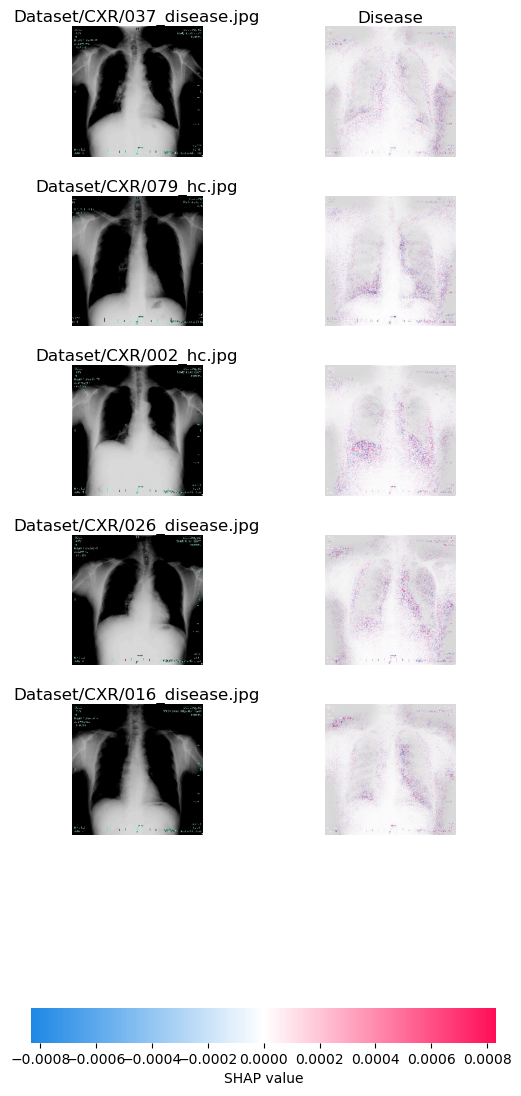

In [ ]:
# # shap_values = [np.swapaxes(np.swapaxes(s, 2, 3), 1, -1) for s in shap_values]
# shap.image_plot(np.transpose(shap_values[...,0],(0,2,3,1)), 
#                 to_explain_tensor.permute(0,2,3,1).numpy(), 
#                 labels=["Disease"] ,
#                 true_labels=to_explain_labels,
#                 width = 500,
#                 aspect = 0.45 ,
#                 hspace = 0.3,
#                 labelpad = 2,
#                 show=False       # IMPORTANT
# )

# plt.savefig(
#     "output-classification/5-Model_explanation/shap_image_plot.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     format = "pdf"
# )

In [20]:
len(np.transpose(shap_values[...,0],(0,2,3,1))) == len(to_explain_tensor.permute(0,2,3,1).numpy())

True

In [41]:
demo_img = SegDataset(samples, transform=demo_transform)

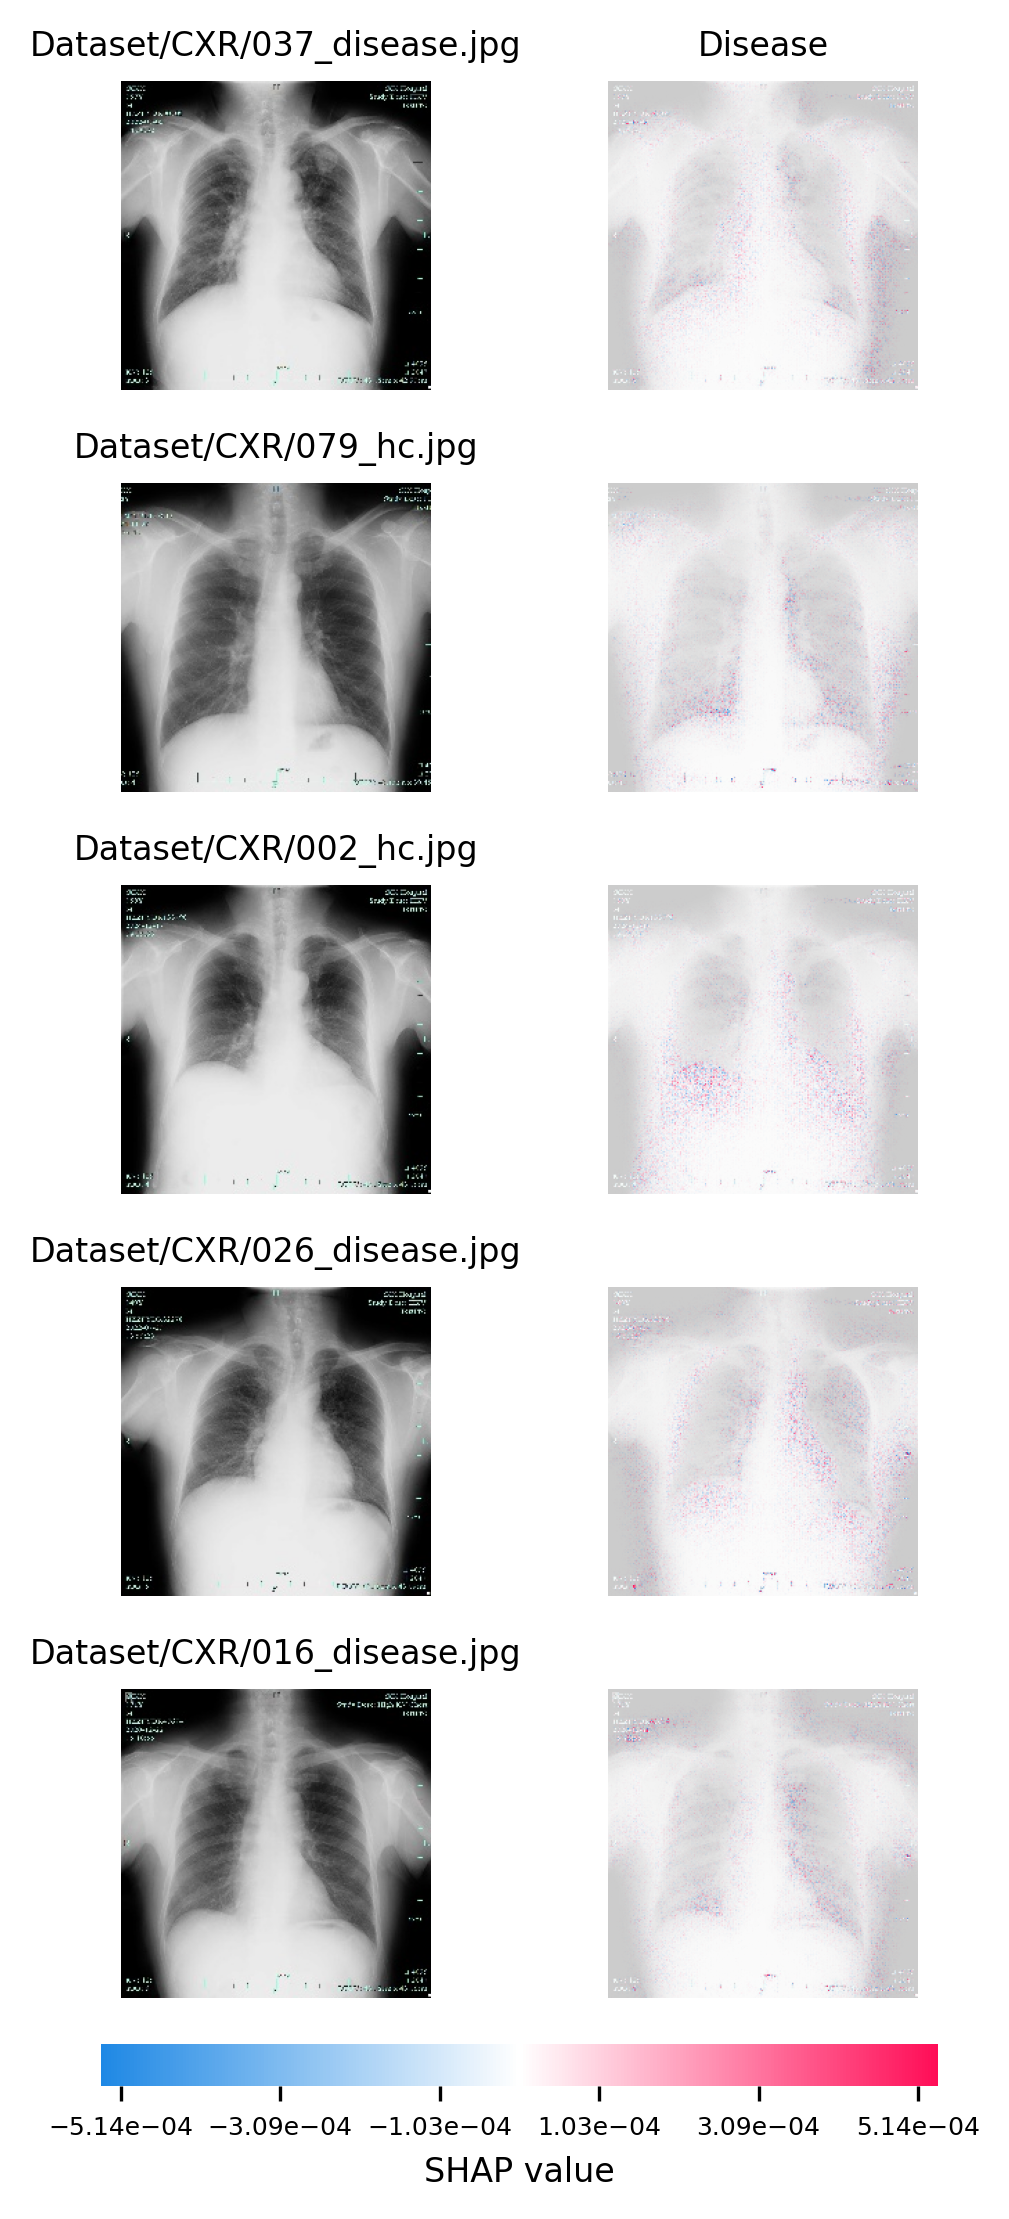

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
colors = []
for j in np.linspace(1, 0, 100):
    colors.append((30.0 / 255, 136.0 / 255, 229.0 / 255, j))
for j in np.linspace(0, 1, 100):
    colors.append((255.0 / 255, 13.0 / 255, 87.0 / 255, j))
red_transparent_blue = LinearSegmentedColormap.from_list("red_transparent_blue", colors)

max_val = np.nanpercentile(abs(shap_values), 99.9) 
padding = max_val * 0.05
fig = plt.figure(figsize=(4, len(samples)*2), dpi=300)

gs = gridspec.GridSpec(
    len(samples), 2,
    # width_ratios=[1, 1],   # ROC wider than confusion matrix
    wspace=0.1,               # space between subplots
    hspace=0.3
)
label_flag = 0
for i in range(len(samples)):
    demo_np,_,_ = demo_img[i]
    # img_np=to_explain_tensor[i].permute(1,2,0).numpy()
    # image = (img_np * 0.5 + 0.5)  # now in [0, 1]
    # image = (img_np * 255)  # optional, 0-255
    ax_img = fig.add_subplot(gs[i, 0])
    ax_img.imshow(demo_np)
    ax_img.set_title(f"{to_explain_labels[i]}", fontsize=8)
    ax_img.axis("off")

    # ---- your custom plot (e.g. SHAP) ----
    ax_shap = fig.add_subplot(gs[i, 1])
    shap_map = np.transpose(shap_values[...,0],(0,2,3,1))[i].mean(axis=-1)  # example
    # print(shap_map)
    ax_shap.imshow(demo_np,alpha=0.2)
    shap_fig = ax_shap.imshow(shap_map, vmin= -max_val-padding, vmax = max_val+padding, cmap=red_transparent_blue)
    if label_flag == 0:
        ax_shap.set_title("Disease",fontsize=8)
        label_flag = 1
    ax_shap.axis("off")

cbar = fig.colorbar(
    shap_fig,
    ax=fig.get_axes(),   # attach to all subplots
    shrink=0.9,
    pad=0.02,
    location = "bottom",
    ticks = np.linspace(-max_val, max_val, 6),
    # extend = "both",
    format = "{x:.2e}"
)

cbar.set_label("SHAP value", fontsize=8)
cbar.ax.tick_params(labelsize=6)  

cbar.outline.set_visible(False) 
plt.savefig("output-classification/6-Model_explanation/shap_image_plot.pdf",
    dpi=300,
    bbox_inches="tight",
    format = "pdf")